# **Prédiction de VSL — pipeline propre**

# Préprocess

## Imports


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, learning_curve,
)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

pd.set_option("display.precision", 3)


## Chargement des données


In [2]:
filepath = r"C:\Users\melan\DESU_DATA_2026\ProjetNR\data2026.xlsx"
raw_df = pd.read_excel(filepath, engine="openpyxl", sheet_name='Total2', header=0,
                       na_values=['na', 'NaN', 'NA', 'N/A', 'n/a', 'nan'])
raw_df.head()
raw_df.shape


(65, 18)

## Split train / test — AVANT tout pretraitement

Règle d'or : **aucune information du test (y compris la cible) ne doit jamais entrer dans
le fit d'un encodeur, d'un imputer, d'un scaler ou d'un modèle.**
On sépare donc X (prédicteurs uniquement, sans la cible) et y (la cible), puis on fait le split.


In [3]:
TARGET_COLUMN = "VSL"
PREDICTOR_COLUMNS = ["P300", "P600", "LNC", "N400", "LRC", "OB", "ON", "Hipp"]

X = raw_df[PREDICTOR_COLUMNS].copy()
y = raw_df[TARGET_COLUMN].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

print(f"Cible : {TARGET_COLUMN}")
print(f"Train : {X_train.shape[0]} patients | Test : {X_test.shape[0]} patients")


Cible : VSL
Train : 58 patients | Test : 7 patients


## Encodage de `Hipp`

L'encodeur est **fit uniquement sur `X_train`**, puis simplement appliqué (`transform`) sur
`X_test` avec `handle_unknown="ignore"` au cas où une catégorie rare n'apparaîtrait que dans le test.


In [4]:
def encode_hipp(df, encoder, fit=False):
    df = df.copy()
    if fit:
        encoded = encoder.fit_transform(df[["Hipp"]])
    else:
        encoded = encoder.transform(df[["Hipp"]])
    hipp_columns = encoder.get_feature_names_out(["Hipp"])
    encoded_df = pd.DataFrame(encoded, columns=hipp_columns, index=df.index)
    return pd.concat([df.drop(columns=["Hipp"]), encoded_df], axis=1)

hipp_encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

X_train = encode_hipp(X_train, hipp_encoder, fit=True)
X_test = encode_hipp(X_test, hipp_encoder, fit=False)

X_train.head()


,P300,P600,LNC,N400,LRC,OB,ON,Hipp_NI,Hipp_ZE,Hipp_ZP
12,-125.3,92.5,-21.6,-54.0,11.2,NaN,NaN,1.0,0.0,0.0
64,-48.4,33.7,-53.2,NaN,NaN,NaN,NaN,0.0,0.0,1.0
30,0.0,113.2,-73.1,NaN,NaN,1,81/81,0.0,0.0,1.0
33,0.0,168.0,-74.2,-11.0,0.0,98%,80/77,0.0,1.0,0.0
9,-105.0,79.3,-18.8,NaN,NaN,0.94,68/43,1.0,0.0,0.0


## Nettoyage des données (colonnes trop incomplètes)

Le seuil de suppression est calculé **uniquement sur `X_train`**, puis la même liste de colonnes
est retirée de `X_test` — sans jamais regarder les valeurs du test pour décider quoi supprimer.


In [5]:
percent_missing = X_train.isnull().sum() * 100 / len(X_train)
percent_missing.sort_values(ascending=False, inplace=True)
percent_missing


ON         60.345
OB         58.621
LRC        36.207
N400       36.207
P600        3.448
P300        3.448
LNC         3.448
Hipp_NI     0.000
Hipp_ZE     0.000
Hipp_ZP     0.000
dtype: float64

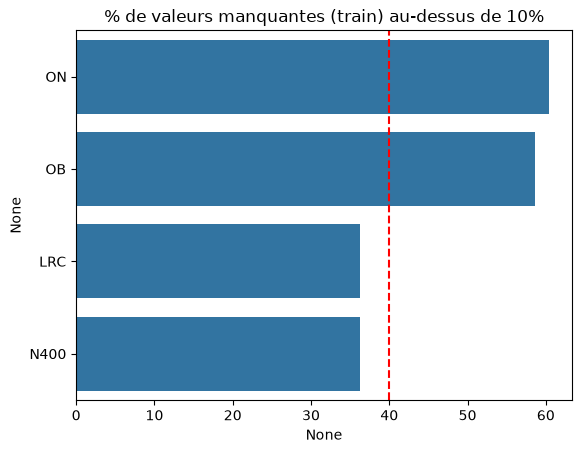

In [6]:
threshold_view = 10
filtered = percent_missing[percent_missing.values > threshold_view]

threshold = 40
if len(filtered) > 0:
    ax = sns.barplot(x=filtered, y=filtered.index, orient='h')
    ax.set_title(f"% de valeurs manquantes (train) au-dessus de {threshold_view}%")
    ax.axvline(x=threshold, color='r', linestyle='--', label=f"Seuil de {threshold}")
else:
    print("Aucune colonne au-dessus du seuil d'affichage.")


In [7]:
columns_to_drop = percent_missing[percent_missing.values > threshold].index

X_train = X_train.drop(columns=columns_to_drop, errors="ignore")
X_test = X_test.drop(columns=columns_to_drop, errors="ignore")

print(f"Colonnes supprimées (> {threshold}% manquant sur le train) : {list(columns_to_drop)}")
X_train.shape, X_test.shape


Colonnes supprimées (> 40% manquant sur le train) : ['ON', 'OB']


((58, 8), (7, 8))

### Retirer les lignes où la cible (`VSL`) est manquante

On n'impute jamais la variable à prédire : impossible d'entraîner ou d'évaluer sur une ligne
dont on ne connaît pas la vraie réponse. On filtre donc train et test séparément.


In [8]:
train_mask = y_train.notna()
test_mask = y_test.notna()

print(f"Lignes retirées (train, {TARGET_COLUMN} manquant) : {(~train_mask).sum()}")
print(f"Lignes retirées (test, {TARGET_COLUMN} manquant)  : {(~test_mask).sum()}")

X_train = X_train.loc[train_mask.index[train_mask]]
y_train = y_train.loc[train_mask]

X_test = X_test.loc[test_mask]
y_test = y_test.loc[test_mask]

print(f"Train final : {X_train.shape[0]} patients | Test final : {X_test.shape[0]} patients")


Lignes retirées (train, VSL manquant) : 4
Lignes retirées (test, VSL manquant)  : 0
Train final : 54 patients | Test final : 7 patients


## Plot représentation train


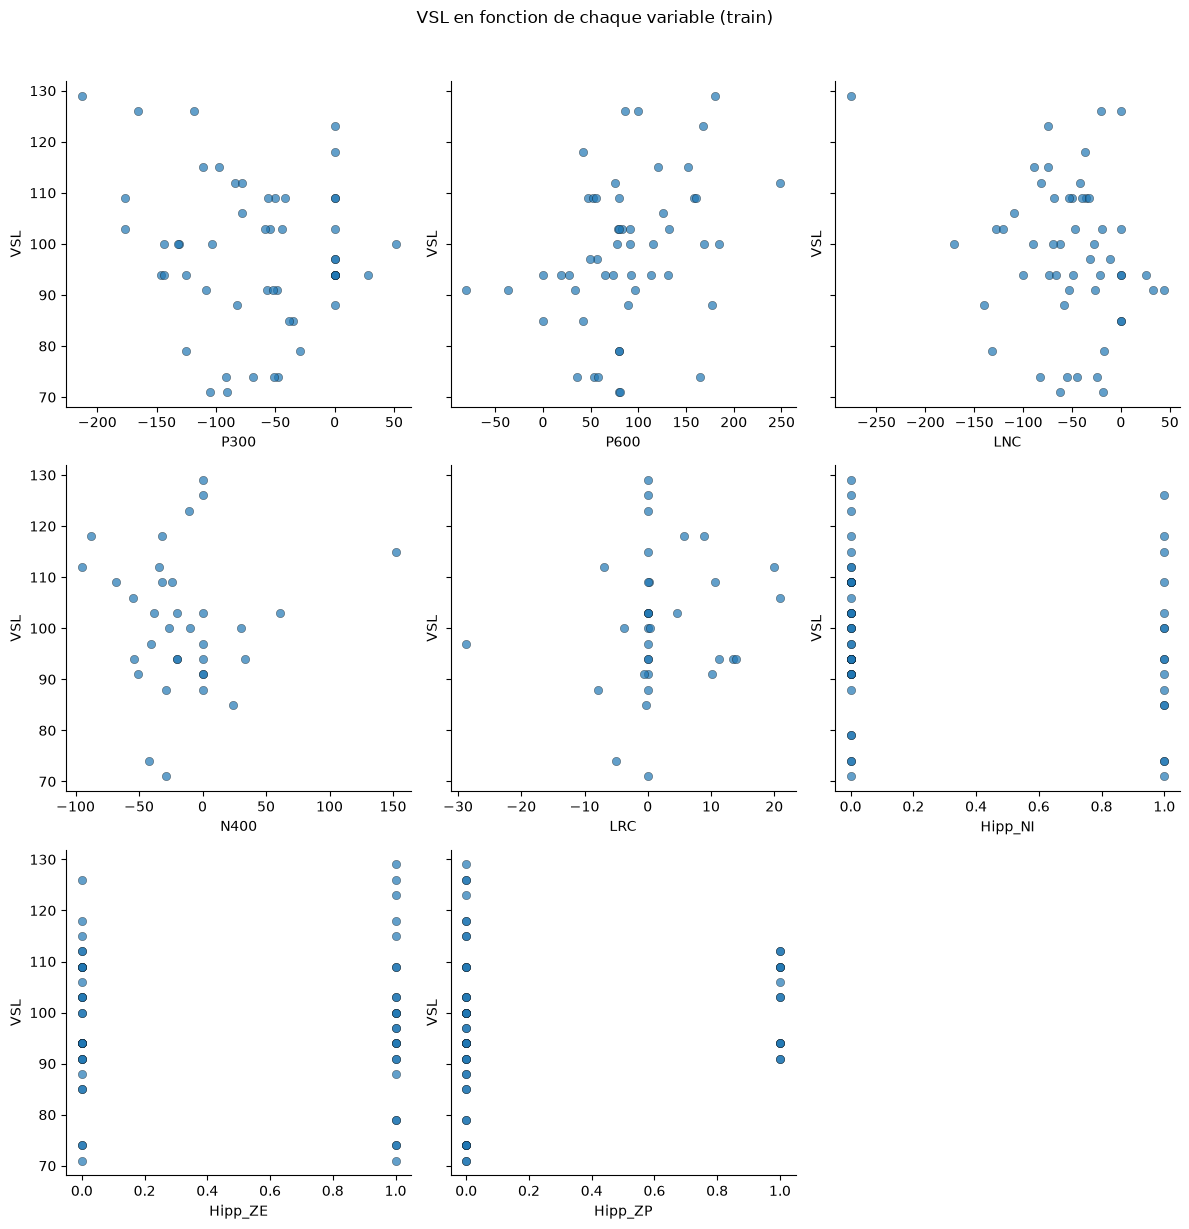

In [9]:
n_cols = 3
n_rows = int(np.ceil(len(X_train.columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows), sharey=True)
axes = axes.flatten()

for ax, feature in zip(axes, X_train.columns):
    ax.scatter(X_train[feature], y_train, alpha=0.7, edgecolor="k", linewidth=0.3)
    ax.set_xlabel(feature)
    ax.set_ylabel("VSL")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

for ax in axes[len(X_train.columns):]:
    ax.axis("off")

fig.suptitle("VSL en fonction de chaque variable (train)", y=1.02)
plt.tight_layout()
plt.show()


## Discrétisation VSL


In [10]:
# y_train / y_test sont des Series (colonne VSL) : on les convertit en DataFrame
y_train_df = y_train.to_frame(name="VSL")
y_test_df = y_test.to_frame(name="VSL")

# Bornes calculées UNIQUEMENT sur le train (jamais sur le test, pour éviter une fuite)
bin_edges = [
    y_train_df["VSL"].min() - 1,
    y_train_df["VSL"].quantile(1 / 3),
    y_train_df["VSL"].quantile(2 / 3),
    y_train_df["VSL"].max() + 1,
]
labels = ["bad", "medium", "good"]

y_train_df["VSL_Category"] = pd.cut(x=y_train_df["VSL"], bins=bin_edges, labels=labels)

# On applique les mêmes bornes au test (pas de recalcul sur le test !)
y_test_df["VSL_Category"] = pd.cut(x=y_test_df["VSL"], bins=bin_edges, labels=labels)


## Réduction de dimensions : ACP


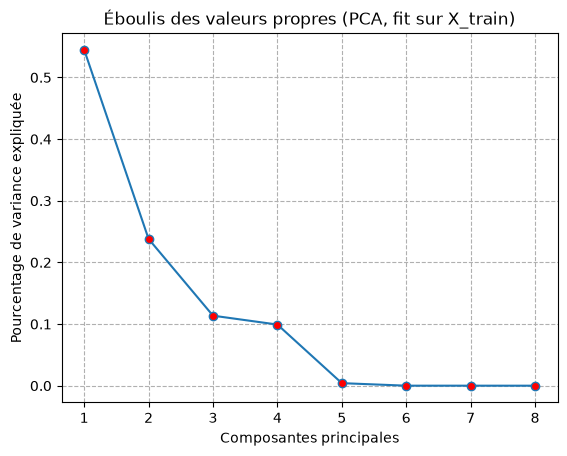

In [11]:
# PCA exploratoire, à but de visualisation uniquement (fit sur X_train).
# La PCA "officielle" utilisée dans les pipelines de modélisation plus bas est
# refit indépendamment à chaque pli de cross-validation : celle-ci ne sert qu'à
# choisir un nombre de composantes raisonnable.
# X_train contient encore des valeurs manquantes à ce stade : on impute
# temporairement (KNNImputer) pour pouvoir fitter la PCA.
X_train_imputed_for_pca = KNNImputer().fit_transform(X_train)

pca_explore = PCA()
pca_explore.fit(X_train_imputed_for_pca)

explained_variance_ratio = pca_explore.explained_variance_ratio_

plt.plot(
    range(1, len(explained_variance_ratio) + 1),
    explained_variance_ratio,
    marker="o",
    markerfacecolor="r",
)
plt.xlabel("Composantes principales")
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.ylabel("Pourcentage de variance expliquée")
plt.grid(linestyle="--")
plt.title("Éboulis des valeurs propres (PCA, fit sur X_train)")
plt.show()


In [12]:
cumulative_variance = np.cumsum(explained_variance_ratio)
n_components = int(np.argmax(cumulative_variance >= 0.90) + 1)

print(f"Variance expliquée cumulée par composante : {np.round(cumulative_variance, 3)}")
print(f"Nombre de composantes retenues pour atteindre 90% de variance : {n_components}")


Variance expliquée cumulée par composante : [0.545 0.783 0.897 0.996 1.    1.    1.    1.   ]
Nombre de composantes retenues pour atteindre 90% de variance : 4


# Comparaison des modèles Logistic Regression, LDA, SVC, Random Forest, Gradient Boosting

Le `StandardScaler` et la `PCA` restent dans la `Pipeline` pour être re-fit à chaque pli de la CV
(pas de fuite de données du pli de validation vers le pli d'entraînement).
Le test (`X_test`, `y_test`) reste intouché jusqu'à l'évaluation finale.

Chaque `GridSearchCV` est lancé une seule fois avec plusieurs métriques (`Accuracy`, `F1_macro`,
`Balanced_accuracy`) : on récupère toutes les métriques du meilleur jeu de paramètres directement
depuis `cv_results_`, sans relancer une seconde cross-validation.


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import warnings
warnings.filterwarnings("ignore")

# ==========================
# Données
# ==========================
X = X_train
y = y_train_df["VSL_Category"]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
imputer = KNNImputer()

# ==========================
# Grilles
# ==========================
param_grids = {

    "Logistic Regression": (
        LogisticRegression(max_iter=10000),
        {
            "model__C": [0.01, 0.1, 1, 10],
            "model__penalty": ["l2"],
        },
    ),

    "LDA": (
        LinearDiscriminantAnalysis(),
        {
            "model__solver": ["svd", "lsqr"],
        },
    ),

    "SVC": (
        SVC(),
        {
            "model__C": [0.1, 1, 10],
            "model__gamma": ["scale", "auto"],
            "model__kernel": ["rbf", "linear"],
        },
    ),

    "Random Forest": (
        RandomForestClassifier(random_state=42),
        {
            "model__n_estimators": [100, 300],
            "model__max_depth": [None, 3, 5],
            "model__min_samples_leaf": [1, 2, 4],
        },
    ),

    "Gradient Boosting": (
        GradientBoostingClassifier(random_state=42),
        {
            "model__n_estimators": [100, 200],
            "model__max_depth": [2, 3],
            "model__learning_rate": [0.01, 0.1],
        },
    ),
}

scoring = {
    "Accuracy": "accuracy",
    "F1_macro": "f1_macro",
    "Balanced_accuracy": "balanced_accuracy",
}

# ==========================
# Grid Search (une seule CV par modèle, toutes les métriques lues dans cv_results_)
# ==========================
models = {}
results = []

for name, (estimator, grid) in param_grids.items():

    pipeline = Pipeline([
        ("imputer", imputer),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n_components)),
        ("model", estimator),
    ])

    grid_search = GridSearchCV(
        pipeline,
        param_grid=grid,
        scoring=scoring,
        refit="F1_macro",
        cv=cv,
        n_jobs=1,
    )

    grid_search.fit(X, y)

    # on conserve le pipeline complet
    models[name] = grid_search.best_estimator_

    best_idx = grid_search.best_index_
    cvres = grid_search.cv_results_

    results.append({
        "Model": name,
        "Accuracy_mean": cvres["mean_test_Accuracy"][best_idx],
        "F1_macro_mean": cvres["mean_test_F1_macro"][best_idx],
        "Balanced_accuracy_mean": cvres["mean_test_Balanced_accuracy"][best_idx],
        "Best params": grid_search.best_params_,
    })

    print(
        f"{name} : meilleurs paramètres = "
        f"{grid_search.best_params_} "
        f"(F1_macro = {cvres['mean_test_F1_macro'][best_idx]:.3f})"
    )

results_df = (
    pd.DataFrame(results)
    .sort_values("Accuracy_mean", ascending=False)
    .reset_index(drop=True)
)

display(results_df)


Logistic Regression : meilleurs paramètres = {'model__C': 1, 'model__penalty': 'l2'} (F1_macro = 0.308)
LDA : meilleurs paramètres = {'model__solver': 'svd'} (F1_macro = 0.313)
SVC : meilleurs paramètres = {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'linear'} (F1_macro = 0.335)
Random Forest : meilleurs paramètres = {'model__max_depth': 3, 'model__min_samples_leaf': 2, 'model__n_estimators': 100} (F1_macro = 0.336)
Gradient Boosting : meilleurs paramètres = {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 200} (F1_macro = 0.296)


,Model,Accuracy_mean,F1_macro_mean,Balanced_accuracy_mean,Best params
0,SVC,0.445,0.335,0.373,"{'model__C': 1, 'model__gamma': 'scale', 'mode..."
1,LDA,0.425,0.313,0.357,{'model__solver': 'svd'}
2,Logistic Regression,0.387,0.308,0.333,"{'model__C': 1, 'model__penalty': 'l2'}"
3,Random Forest,0.387,0.336,0.368,"{'model__max_depth': 3, 'model__min_samples_le..."
4,Gradient Boosting,0.333,0.296,0.308,"{'model__learning_rate': 0.01, 'model__max_dep..."


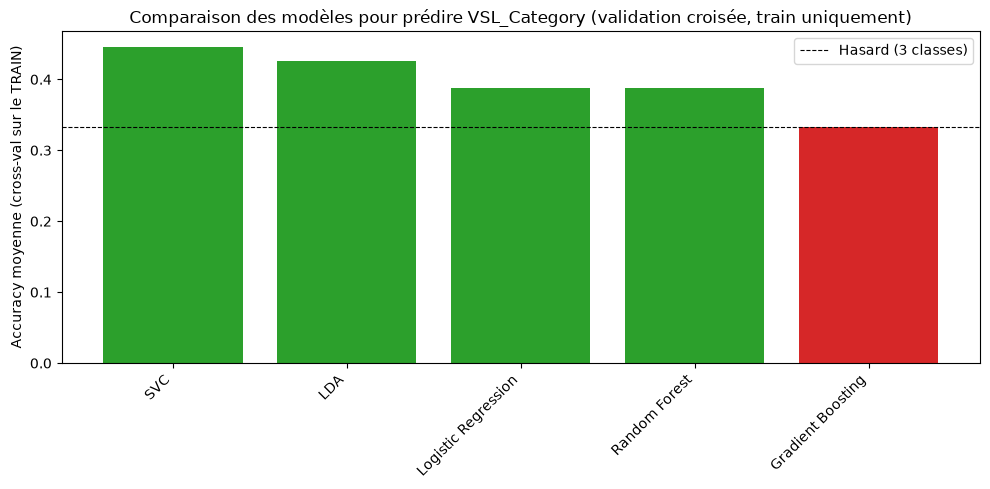

In [14]:
plt.figure(figsize=(10, 5))
colors = ["#2ca02c" if acc >= 1/3 else "#d62728" for acc in results_df["Accuracy_mean"]]
plt.bar(results_df["Model"], results_df["Accuracy_mean"], color=colors)

# Ligne de référence : accuracy d'un classifieur "au hasard" pour 3 classes équilibrées
plt.axhline(1/3, color="black", linewidth=0.8, linestyle="--", label="Hasard (3 classes)")

plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy moyenne (cross-val sur le TRAIN)")
plt.title(f"Comparaison des modèles pour prédire {TARGET_COLUMN}_Category (validation croisée, train uniquement)")
plt.legend()
plt.tight_layout()
plt.show()


### Sélection du meilleur modèle et évaluation UNIQUE sur le test

Le modèle est choisi selon le meilleur **sur le train**. On l'entraîne
ensuite une seule fois sur tout le train, puis on l'évalue **une seule fois** sur le test —
la seule métrique qui compte pour juger de la performance réelle hors échantillon.


In [15]:
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score

# Meilleur modèle sélectionné
best_model_name = results_df.iloc[0]["Model"]
final_pipeline = models[best_model_name]

# Données de test
y_test_cat = y_test_df["VSL_Category"]

# Entraînement sur tout le train
final_pipeline.fit(X_train, y)

# Prédiction sur le test
y_pred_test = final_pipeline.predict(X_test)

# Métriques
test_accuracy = accuracy_score(y_test_cat, y_pred_test)
test_f1_macro = f1_score(y_test_cat, y_pred_test, average="macro")
test_balanced_accuracy = balanced_accuracy_score(y_test_cat, y_pred_test)

summary_test = pd.DataFrame([{
    "Modèle retenu": best_model_name,
    "Accuracy (test)": round(test_accuracy, 3),
    "F1_macro (test)": round(test_f1_macro, 3),
    "Balanced accuracy (test)": round(test_balanced_accuracy, 3),
    "Accuracy CV (train)": round(results_df.iloc[0]["Accuracy_mean"], 3),
}])

summary_test


,Modèle retenu,Accuracy (test),F1_macro (test),Balanced accuracy (test),Accuracy CV (train)
0,SVC,0.286,0.167,0.333,0.445


### Visualisation : valeurs prédites vs valeurs réelles TRAIN/TEST


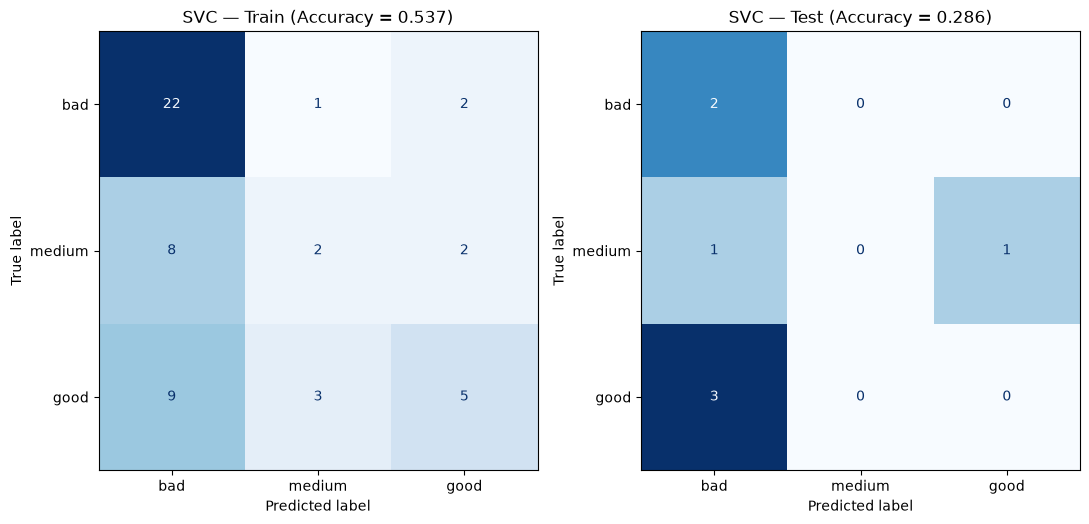

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred_train = final_pipeline.predict(X_train)
train_accuracy = accuracy_score(y, y_pred_train)

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))

ConfusionMatrixDisplay.from_predictions(
    y,
    y_pred_train,
    labels=["bad", "medium", "good"],
    cmap="Blues",
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title(f"{best_model_name} — Train (Accuracy = {train_accuracy:.3f})")

ConfusionMatrixDisplay.from_predictions(
    y_test_cat,
    y_pred_test,
    labels=["bad", "medium", "good"],
    cmap="Blues",
    ax=axes[1],
    colorbar=False,
)
axes[1].set_title(f"{best_model_name} — Test (Accuracy = {test_accuracy:.3f})")

plt.tight_layout()
plt.show()


### Learning curve du modèle réellement retenu (sur le train)


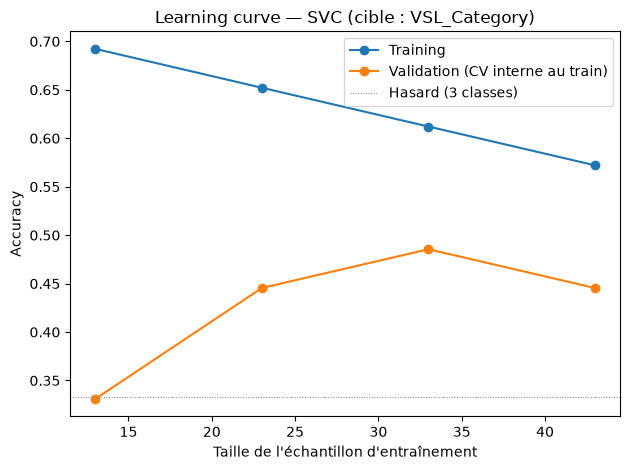

Cible prédite : VSL_Category (bad / medium / good)
Échantillon   : 54 (train) / 7 (test)

Classement des modèles (CV sur le train) :
              Model  Accuracy_mean  F1_macro_mean  Balanced_accuracy_mean                                                                       Best params
                SVC          0.445          0.335                   0.373               {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'linear'}
                LDA          0.425          0.313                   0.357                                                          {'model__solver': 'svd'}
Logistic Regression          0.387          0.308                   0.333                                           {'model__C': 1, 'model__penalty': 'l2'}
      Random Forest          0.387          0.336                   0.368 {'model__max_depth': 3, 'model__min_samples_leaf': 2, 'model__n_estimators': 100}
  Gradient Boosting          0.333          0.296                   0.308 {'model__lear

In [17]:
train_sizes, train_scores, val_scores = learning_curve(
    final_pipeline,
    X,
    y,
    cv=cv,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5),
)

plt.plot(train_sizes, np.mean(train_scores, axis=1), marker="o", label="Training")
plt.plot(train_sizes, np.mean(val_scores, axis=1), marker="o", label="Validation (CV interne au train)")
plt.axhline(1/3, color="grey", linewidth=0.7, linestyle=":", label="Hasard (3 classes)")
plt.xlabel("Taille de l'échantillon d'entraînement")
plt.ylabel("Accuracy")
plt.title(f"Learning curve — {best_model_name} (cible : {TARGET_COLUMN}_Category)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Cible prédite : {TARGET_COLUMN}_Category (bad / medium / good)")
print(f"Échantillon   : {X.shape[0]} (train) / {X_test.shape[0]} (test)")
print()
print("Classement des modèles (CV sur le train) :")
print(results_df.to_string(index=False))
print()
print("Performance du modèle retenu sur le test (jamais vu avant) :")
print(summary_test.to_string(index=False))


# OneVsRestClassifier

Section indépendante : on teste ici un `OneVsRestClassifier` (Régression Logistique) en plus des
modèles ci-dessus, sans le mélanger au tableau comparatif principal.


In [18]:
from sklearn.multiclass import OneVsRestClassifier

param_grid_ovr = {
    "model__estimator__C": [0.01, 0.1, 1, 10],
    "model__estimator__penalty": ["l2"],
    "model__estimator__solver": ["lbfgs"],
}

pipeline_ovr = Pipeline([
    ("imputer", imputer),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=n_components)),
    ("model", OneVsRestClassifier(LogisticRegression(max_iter=1000))),
])

grid_search_ovr = GridSearchCV(
    pipeline_ovr,
    param_grid=param_grid_ovr,
    scoring=scoring,
    refit="F1_macro",
    cv=cv,
    n_jobs=1,
)

grid_search_ovr.fit(X, y)

models["OneVsRest"] = grid_search_ovr.best_estimator_

best_idx_ovr = grid_search_ovr.best_index_
cvres_ovr = grid_search_ovr.cv_results_

ovr_cv_summary = {
    "Model": "OneVsRest",
    "Accuracy_mean": cvres_ovr["mean_test_Accuracy"][best_idx_ovr],
    "F1_macro_mean": cvres_ovr["mean_test_F1_macro"][best_idx_ovr],
    "Balanced_accuracy_mean": cvres_ovr["mean_test_Balanced_accuracy"][best_idx_ovr],
    "Best params": grid_search_ovr.best_params_,
}

print(
    f"OneVsRest : meilleurs paramètres = "
    f"{grid_search_ovr.best_params_} "
    f"(F1_macro = {cvres_ovr['mean_test_F1_macro'][best_idx_ovr]:.3f})"
)

pd.DataFrame([ovr_cv_summary])


OneVsRest : meilleurs paramètres = {'model__estimator__C': 10, 'model__estimator__penalty': 'l2', 'model__estimator__solver': 'lbfgs'} (F1_macro = 0.324)


,Model,Accuracy_mean,F1_macro_mean,Balanced_accuracy_mean,Best params
0,OneVsRest,0.405,0.324,0.356,"{'model__estimator__C': 10, 'model__estimator_..."


In [19]:
final_pipeline = models["OneVsRest"]

# Données de test
y_test_cat = y_test_df["VSL_Category"]

# Entraînement sur tout le train
final_pipeline.fit(X_train, y)

# Prédiction sur le test
y_pred_test = final_pipeline.predict(X_test)

# Métriques
test_accuracy = accuracy_score(y_test_cat, y_pred_test)
test_f1_macro = f1_score(y_test_cat, y_pred_test, average="macro")
test_balanced_accuracy = balanced_accuracy_score(y_test_cat, y_pred_test)

summary_test_ovr = pd.DataFrame([{
    "Modèle": "OneVsRest",
    "Accuracy (test)": round(test_accuracy, 3),
    "F1_macro (test)": round(test_f1_macro, 3),
    "Balanced accuracy (test)": round(test_balanced_accuracy, 3),
    "Accuracy CV (train)": round(ovr_cv_summary["Accuracy_mean"], 3),
}])

summary_test_ovr


,Modèle,Accuracy (test),F1_macro (test),Balanced accuracy (test),Accuracy CV (train)
0,OneVsRest,0.286,0.19,0.333,0.405


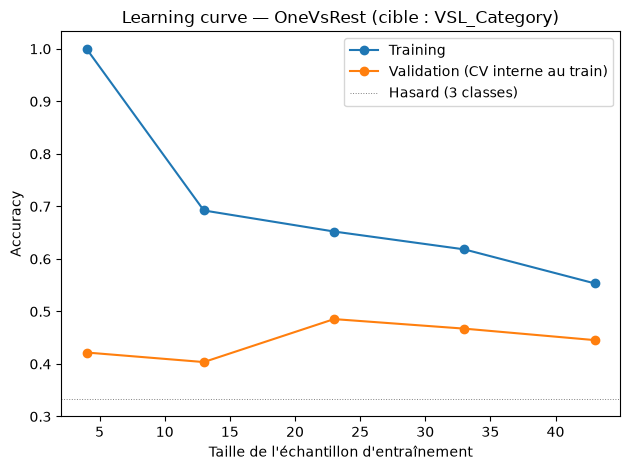

Cible prédite : VSL_Category (bad / medium / good)
Échantillon   : 54 (train) / 7 (test)

Performance du OneVsRestClassifier sur le test (jamais vu avant) :
   Modèle  Accuracy (test)  F1_macro (test)  Balanced accuracy (test)  Accuracy CV (train)
OneVsRest            0.286             0.19                     0.333                0.405


In [20]:
train_sizes, train_scores, val_scores = learning_curve(
    final_pipeline,
    X,
    y,
    cv=cv,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5),
)

plt.plot(train_sizes, np.mean(train_scores, axis=1), marker="o", label="Training")
plt.plot(train_sizes, np.mean(val_scores, axis=1), marker="o", label="Validation (CV interne au train)")
plt.axhline(1/3, color="grey", linewidth=0.7, linestyle=":", label="Hasard (3 classes)")
plt.xlabel("Taille de l'échantillon d'entraînement")
plt.ylabel("Accuracy")
plt.title(f"Learning curve — OneVsRest (cible : {TARGET_COLUMN}_Category)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Cible prédite : {TARGET_COLUMN}_Category (bad / medium / good)")
print(f"Échantillon   : {X.shape[0]} (train) / {X_test.shape[0]} (test)")
print()
print("Performance du OneVsRestClassifier sur le test (jamais vu avant) :")
print(summary_test_ovr.to_string(index=False))


## Analyse des résidus

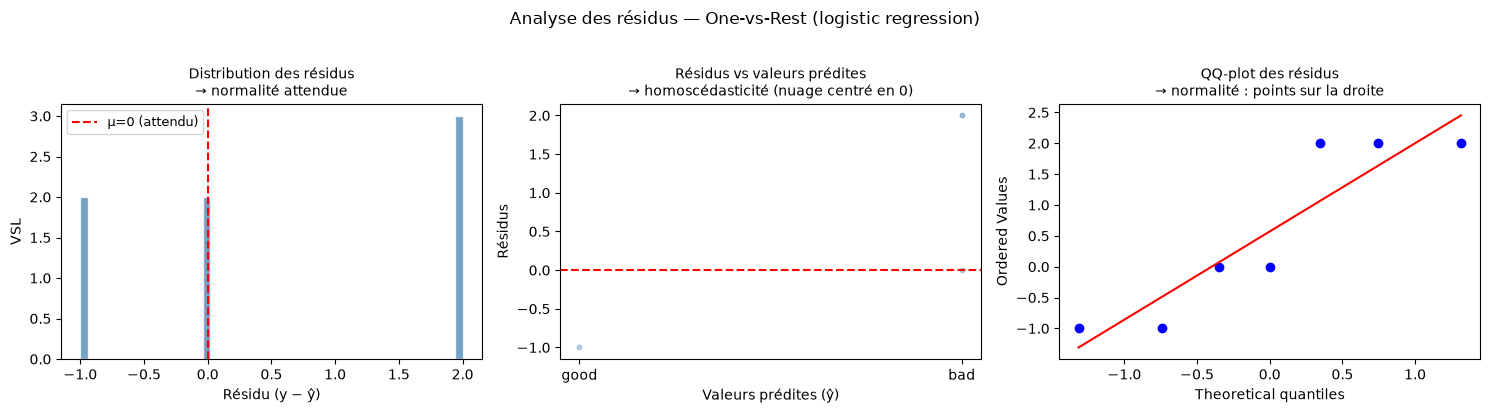

Moyenne des résidus : 0.571  (attendu : ≈ 0)
Médiane des résidus : 0.000


In [21]:
import scipy.stats

category_to_num = {"bad": 0, "medium": 1, "good": 2}

y_true_num = y_test_cat.map(category_to_num).to_numpy()
y_pred_num = pd.Series(y_pred_test, index=y_test_cat.index).map(category_to_num).to_numpy()

residuals = y_true_num - y_pred_num

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Distribution des résidus
axes[0].hist(residuals, bins=50, color='steelblue', alpha=0.75, edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='μ=0 (attendu)')
axes[0].set_title('Distribution des résidus\n→ normalité attendue', fontsize=10)
axes[0].set_xlabel('Résidu (y − ŷ)')
axes[0].set_ylabel('VSL')
axes[0].legend(fontsize=9)

# 2. Résidus vs valeurs prédites (homoscédasticité)
axes[1].scatter(y_pred_test, residuals, alpha=0.2, color='steelblue', s=10)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Résidus vs valeurs prédites\n→ homoscédasticité (nuage centré en 0)', fontsize=10)
axes[1].set_xlabel('Valeurs prédites (ŷ)')
axes[1].set_ylabel('Résidus')

# 3. QQ-plot
scipy.stats.probplot(residuals, dist='norm', plot=axes[2])
axes[2].set_title('QQ-plot des résidus\n→ normalité : points sur la droite', fontsize=10)

plt.suptitle('Analyse des résidus — One-vs-Rest (logistic regression)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print(f'Moyenne des résidus : {residuals.mean():.3f}  (attendu : ≈ 0)')
print(f'Médiane des résidus : {np.median(residuals):.3f}')

# DecisionTree

In [22]:
from sklearn.tree import DecisionTreeClassifier

param_grid_dt = {
    "model__max_depth": [2, 3, 4, 5, None],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__criterion": ["gini", "entropy"],
}

pipeline_dt = Pipeline([
    ("imputer", imputer),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=n_components)),
    ("model", DecisionTreeClassifier(random_state=42)),
])

grid_search_dt = GridSearchCV(
    pipeline_dt,
    param_grid=param_grid_dt,
    scoring=scoring,
    refit="F1_macro",
    cv=cv,
    n_jobs=1,
)

grid_search_dt.fit(X, y)

models["Decision Tree"] = grid_search_dt.best_estimator_

best_idx_dt = grid_search_dt.best_index_
cvres_dt = grid_search_dt.cv_results_

dt_cv_summary = {
    "Model": "Decision Tree",
    "Accuracy_mean": cvres_dt["mean_test_Accuracy"][best_idx_dt],
    "F1_macro_mean": cvres_dt["mean_test_F1_macro"][best_idx_dt],
    "Balanced_accuracy_mean": cvres_dt["mean_test_Balanced_accuracy"][best_idx_dt],
    "Best params": grid_search_dt.best_params_,
}

print(
    f"Decision Tree : meilleurs paramètres = "
    f"{grid_search_dt.best_params_} "
    f"(F1_macro = {cvres_dt['mean_test_F1_macro'][best_idx_dt]:.3f})"
)

pd.DataFrame([dt_cv_summary])

Decision Tree : meilleurs paramètres = {'model__criterion': 'entropy', 'model__max_depth': 3, 'model__min_samples_leaf': 1} (F1_macro = 0.296)


,Model,Accuracy_mean,F1_macro_mean,Balanced_accuracy_mean,Best params
0,Decision Tree,0.351,0.296,0.308,"{'model__criterion': 'entropy', 'model__max_de..."


In [23]:
final_pipeline = models["Decision Tree"]

# Données de test
y_test_cat = y_test_df["VSL_Category"]

# Entraînement sur tout le train
final_pipeline.fit(X_train, y)

# Prédiction sur le test
y_pred_test = final_pipeline.predict(X_test)

# Métriques
test_accuracy = accuracy_score(y_test_cat, y_pred_test)
test_f1_macro = f1_score(y_test_cat, y_pred_test, average="macro")
test_balanced_accuracy = balanced_accuracy_score(y_test_cat, y_pred_test)

summary_test_dt = pd.DataFrame([{
    "Modèle": "Decision Tree",
    "Accuracy (test)": round(test_accuracy, 3),
    "F1_macro (test)": round(test_f1_macro, 3),
    "Balanced accuracy (test)": round(test_balanced_accuracy, 3),
    "Accuracy CV (train)": round(dt_cv_summary["Accuracy_mean"], 3),
}])

summary_test_dt

,Modèle,Accuracy (test),F1_macro (test),Balanced accuracy (test),Accuracy CV (train)
0,Decision Tree,0.429,0.389,0.5,0.351


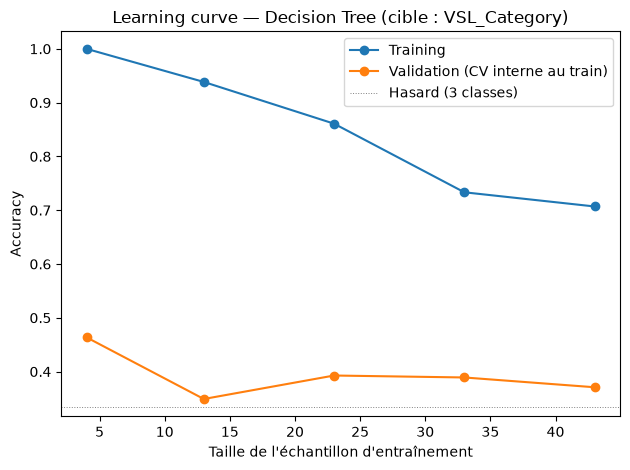

Cible prédite : VSL_Category (bad / medium / good)
Échantillon   : 54 (train) / 7 (test)

Performance du DecisionTreeClassifier sur le test (jamais vu avant) :
       Modèle  Accuracy (test)  F1_macro (test)  Balanced accuracy (test)  Accuracy CV (train)
Decision Tree            0.429            0.389                       0.5                0.351


In [24]:
train_sizes, train_scores, val_scores = learning_curve(
    final_pipeline,
    X,
    y,
    cv=cv,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5),
)

plt.plot(train_sizes, np.mean(train_scores, axis=1), marker="o", label="Training")
plt.plot(train_sizes, np.mean(val_scores, axis=1), marker="o", label="Validation (CV interne au train)")
plt.axhline(1/3, color="grey", linewidth=0.7, linestyle=":", label="Hasard (3 classes)")
plt.xlabel("Taille de l'échantillon d'entraînement")
plt.ylabel("Accuracy")
plt.title(f"Learning curve — Decision Tree (cible : {TARGET_COLUMN}_Category)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Cible prédite : {TARGET_COLUMN}_Category (bad / medium / good)")
print(f"Échantillon   : {X.shape[0]} (train) / {X_test.shape[0]} (test)")
print()
print("Performance du DecisionTreeClassifier sur le test (jamais vu avant) :")
print(summary_test_dt.to_string(index=False))
